# Sesión 01: EDA, calidad de datos, preprocesamiento y pipelines


**Aprendizaje de Máquina Aplicado**

**Profesor:** Marco Teran <br>
**Estudiantes:** Isis Catitza Amaya Arbelaez <br>
Santiago Alberto Rozo Silva <br>
Samuel Oviedo Paz <br>
**Fecha:** 2026


[Github](https://github.com/SamuelOviedo2003/ml-embalses-colombia.git)

In [2]:
# Configuración inicial del entorno
import sys
import warnings

warnings.filterwarnings('ignore')

# Verificar versión de Python
assert sys.version_info >= (3, 7), "Este notebook requiere Python 3.7 o superior"

print(f"Python {sys.version_info.major}.{sys.version_info.minor}.{sys.version_info.micro} instalado correctamente")

Python 3.13.13 instalado correctamente


In [3]:
import sys
!"{sys.executable}" -m pip install numpy pandas matplotlib seaborn scipy scikit-learn category_encoders

Defaulting to user installation because normal site-packages is not writeable


In [4]:
# Importar librerías necesarias
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from typing import Iterable, Optional
from scipy import stats

print("Librerías importadas correctamente")

Librerías importadas correctamente


In [5]:
# Verificar versiones de librerías críticas
from packaging import version
from sklearn.model_selection import train_test_split
import sklearn

assert version.parse(sklearn.__version__) >= version.parse("1.0.1"), "Requiere scikit-learn >= 1.0.1"
print(f"scikit-learn {sklearn.__version__} instalado")

scikit-learn 1.8.0 instalado


In [6]:
def print_section(title: str, width: int = 88) -> None:
    """Print a visual section delimiter."""
    print("\n" + "=" * width)
    print(title.center(width))
    print("=" * width)


def summarize_schema(df: pd.DataFrame, target: Optional[str] = None) -> pd.DataFrame:
    """Return a compact schema summary."""
    summary = pd.DataFrame({
        "column": df.columns,
        "dtype": df.dtypes.astype(str).values,
        "non_null": df.notna().sum().values,
        "missing": df.isna().sum().values,
        "missing_pct": (df.isna().mean().values * 100).round(2),
        "n_unique": df.nunique(dropna=True).values,
    })
    summary["role"] = "feature"
    if target is not None and target in summary["column"].values:
        summary.loc[summary["column"] == target, "role"] = "target"
    return summary.sort_values(["role", "missing_pct", "column"], ascending=[False, False, True]).reset_index(drop=True)


def missing_summary(df: pd.DataFrame) -> pd.DataFrame:
    """Return a missing-value summary sorted by missingness."""
    out = pd.DataFrame({
        "column": df.columns,
        "missing": df.isna().sum().values,
        "missing_pct": (df.isna().mean().values * 100).round(2),
        "dtype": df.dtypes.astype(str).values,
    })
    out = out.sort_values(["missing", "column"], ascending=[False, True]).reset_index(drop=True)
    return out


def detect_duplicate_rows(df: pd.DataFrame) -> pd.DataFrame:
    """Return duplicated rows."""
    dup_mask = df.duplicated(keep=False)
    return df.loc[dup_mask].copy()


def iqr_outlier_rate(series: pd.Series) -> float:
    """Return the percentage of IQR-rule outliers for a numeric series."""
    s = series.dropna()
    if s.empty:
        return 0.0
    q1 = s.quantile(0.25)
    q3 = s.quantile(0.75)
    iqr = q3 - q1
    if iqr == 0:
        return 0.0
    mask = (s < q1 - 1.5 * iqr) | (s > q3 + 1.5 * iqr)
    return round(mask.mean() * 100, 2)


def numeric_profile(df: pd.DataFrame, columns: Iterable[str]) -> pd.DataFrame:
    """Return a robust numeric profile for selected columns."""
    rows = []
    for col in columns:
        s = df[col].dropna()
        rows.append({
            "column": col,
            "mean": s.mean(),
            "median": s.median(),
            "std": s.std(),
            "min": s.min(),
            "q1": s.quantile(0.25),
            "q3": s.quantile(0.75),
            "max": s.max(),
            "skew": s.skew(),
            "outlier_pct_iqr": iqr_outlier_rate(df[col]),
        })
    return pd.DataFrame(rows).round(3)


def plot_missing_matrix(df: pd.DataFrame, max_rows: int = 250) -> None:
    """Visualize missingness as a compact matrix."""
    sample = df.head(max_rows)
    matrix = sample.isna().astype(int).T.values

    fig, ax = plt.subplots(figsize=(12, 4))
    ax.imshow(matrix, aspect="auto", interpolation="nearest")
    ax.set_title("Mapa de missingness (columnas × filas)")
    ax.set_xlabel("Filas (muestra inicial)")
    ax.set_ylabel("Columnas")
    ax.set_yticks(range(len(sample.columns)))
    ax.set_yticklabels(sample.columns)
    ax.set_xticks([])
    plt.tight_layout()
    plt.show()


def plot_missing_bars(df: pd.DataFrame) -> None:
    """Bar plot of missing percentages."""
    miss = missing_summary(df)
    miss = miss[miss["missing"] > 0]
    if miss.empty:
        print("✅ No hay valores faltantes en el dataset de trabajo.")
        return

    fig, ax = plt.subplots(figsize=(10, 4))
    ax.bar(miss["column"], miss["missing_pct"])
    ax.set_title("Porcentaje de valores faltantes por columna")
    ax.set_ylabel("% faltante")
    ax.set_xlabel("Columna")
    ax.axhline(5, linestyle="--", linewidth=1)
    ax.tick_params(axis="x", rotation=45)
    plt.tight_layout()
    plt.show()


def plot_numeric_audit(df: pd.DataFrame, columns: list[str], target: str) -> None:
    """Plot histogram, boxplot, and target scatter for selected numeric columns."""
    for col in columns:
        fig, axes = plt.subplots(1, 3, figsize=(16, 4))

        # Histograma
        axes[0].hist(df[col].dropna(), bins=40, edgecolor="black", alpha=0.8)
        axes[0].axvline(df[col].mean(), linestyle="--", linewidth=1, label=f"Media: {df[col].mean():.2f}")
        axes[0].axvline(df[col].median(), linestyle=":", linewidth=1, label=f"Mediana: {df[col].median():.2f}")
        axes[0].set_title(f"Distribución: {col}")
        axes[0].set_xlabel(col)
        axes[0].set_ylabel("Frecuencia")
        axes[0].legend()

        # Boxplot
        axes[1].boxplot(df[col].dropna(), vert=True, patch_artist=True)
        axes[1].set_title(f"Boxplot: {col}")
        axes[1].set_ylabel(col)

        # Relación con target
        valid = df[[col, target]].dropna()
        axes[2].scatter(valid[col], valid[target], alpha=0.2, s=10)
        axes[2].set_title(f"{col} vs {target}")
        axes[2].set_xlabel(col)
        axes[2].set_ylabel(target)

        plt.tight_layout()
        plt.show()


def plot_categorical_audit(df: pd.DataFrame, cat_col: str, target: str) -> None:
    """Audit a categorical feature."""
    counts = df[cat_col].fillna("MISSING").value_counts(dropna=False)

    fig, axes = plt.subplots(1, 2, figsize=(14, 4))

    axes[0].bar(counts.index.astype(str), counts.values)
    axes[0].set_title(f"Distribución de categorías: {cat_col}")
    axes[0].set_xlabel(cat_col)
    axes[0].set_ylabel("Frecuencia")
    axes[0].tick_params(axis="x", rotation=45)

    grouped = df[[cat_col, target]].copy()
    grouped[cat_col] = grouped[cat_col].fillna("MISSING")
    category_order = counts.index.astype(str).tolist()

    data_for_box = [
        grouped.loc[grouped[cat_col].astype(str) == level, target].dropna().values
        for level in category_order
    ]
    axes[1].boxplot(data_for_box, labels=category_order, patch_artist=True)
    axes[1].set_title(f"{target} por categoría: {cat_col}")
    axes[1].set_xlabel(cat_col)
    axes[1].set_ylabel(target)
    axes[1].tick_params(axis="x", rotation=45)

    plt.tight_layout()
    plt.show()


def plot_correlation_heatmap(df: pd.DataFrame, columns: list[str]) -> None:
    """Simple correlation heatmap using matplotlib only."""
    corr = df[columns].corr(numeric_only=True)

    fig, ax = plt.subplots(figsize=(8, 6))
    im = ax.imshow(corr.values, aspect="auto", interpolation="nearest", vmin=-1, vmax=1)
    ax.set_xticks(range(len(corr.columns)))
    ax.set_xticklabels(corr.columns, rotation=45, ha="right")
    ax.set_yticks(range(len(corr.index)))
    ax.set_yticklabels(corr.index)
    ax.set_title("Matriz de correlación")
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    plt.tight_layout()
    plt.show()


def quick_interpretation(df: pd.DataFrame, target: str, numeric_cols: list[str]) -> None:
    """Print short interpretation cues after EDA."""
    print_section("LECTURA RÁPIDA DEL EDA")
    print(f"- Filas: {df.shape[0]:,}")
    print(f"- Columnas: {df.shape[1]}")
    print(f"- Target: {target}")
    print(f"- Variables numéricas: {len(numeric_cols)}")
    print(f"- Variables categóricas: {df.select_dtypes(exclude=[np.number]).shape[1]}")
    print(f"- Valores faltantes totales: {int(df.isna().sum().sum())}")
    print(f"- Filas duplicadas exactas: {int(df.duplicated().sum())}")


In [20]:

def plot_cross_corr(df, feature, target, max_lag=30):
    lags = range(0, max_lag)
    corrs = [
        df[target].corr(df[feature].shift(lag))
        for lag in lags
    ]

    plt.figure(figsize=(8,4))
    plt.plot(lags, corrs)
    plt.title(f"Cross-correlation: {feature} vs {target}")
    plt.xlabel("Lag (días)")
    plt.ylabel("Correlación")
    plt.axhline(0)
    plt.show()

In [22]:
def plot_lag_scatter(df, feature, target, lag=7):
    plt.figure(figsize=(5,5))
    plt.scatter(df[feature].shift(lag), df[target], alpha=0.3)
    plt.xlabel(f"{feature} (lag {lag})")
    plt.ylabel(target)
    plt.title(f"{feature}_lag{lag} vs {target}")
    plt.show()

In [24]:
def plot_time_series(df, feature, embalse):
    data = df[df["CodigoEmbalse"] == embalse]

    plt.figure(figsize=(10,4))
    plt.plot(data["Fecha"], data["reserva_pct"], label="reserva")
    plt.plot(data["Fecha"], data[feature], label=feature, alpha=0.7)
    plt.legend()
    plt.title(f"{feature} vs reserva - {embalse}")
    plt.show()

In [25]:
import seaborn as sns

def lag_corr_matrix(df, feature, target, max_lag=15):
    data = {
        f"{feature}_lag_{lag}": df[feature].shift(lag)
        for lag in range(1, max_lag)
    }
    lag_df = pd.DataFrame(data)
    lag_df[target] = df[target]

    corr = lag_df.corr()

    plt.figure(figsize=(6,6))
    sns.heatmap(corr[[target]].sort_values(by=target, ascending=False), annot=True, cmap="coolwarm")
    plt.title(f"Lag correlation: {feature}")
    plt.show()

In [7]:
# Ruta al dataset
data_path = Path("Datasets/dataset_final.csv")

# Cargar dataset
embalses = pd.read_csv(data_path)

# Definir target
TARGET = "reserva_pct" 

print(f"✅ Dataset cargado desde: {data_path}")
print(f"✅ Shape: {embalses.shape[0]:,} filas × {embalses.shape[1]} columnas")

✅ Dataset cargado desde: Datasets\dataset_final.csv
✅ Shape: 99,838 filas × 17 columnas


In [8]:
embalses = embalses[embalses['CodigoEmbalse'] != 'AGREGADO_SIN']

embalses["Fecha"] = pd.to_datetime(embalses["Fecha"])

embalses = embalses[embalses["Fecha"] < "2025-01-01"]

# Verificar que se eliminó
#print(embalses['CodigoEmbalse'].value_counts())
print(embalses['CodigoEmbalse'].unique())
#print(f"\nRegistros restantes: {len(embalses)}")
#print(embalses[embalses["CodigoEmbalse"] == "AGREGADO"])

<StringArray>
['AGREGADO_BOGOTA',        'ALTOANCH',         'BETANIA',         'CALIMA1',
           'CHUZA',        'ESMERALD',          'GUAVIO',           'MIEL1',
        'MIRAFLOR',            'MUNA',           'PENOL',          'PLAYAS',
          'PORCE2',          'PORCE3',           'PRADO',        'PUNCHINA',
        'RIOGRAN2',        'SALVAJIN',        'SANLOREN',        'TRONERAS',
           'URRA1',        'SOGAMOSO',        'ELQUIMBO',         'ITUANGO']
Length: 24, dtype: str


In [9]:
print_section("PRIMERA INSPECCIÓN")

display(embalses.head())

print("\nTipos de datos:")
display(embalses.dtypes.to_frame(name="dtype").T)

print("\nDescripción numérica rápida:")
display(embalses.describe(include=[np.number]).T)


                                   PRIMERA INSPECCIÓN                                   


,Fecha,CodigoEmbalse,RegionHidrologica,reserva_pct,aportes_masa,media_historica_masa,aportes_vs_media_pct,t2m,u10,v10,msl,sst_nino,tp,ro,sro,swvl1,wind_speed
0,2013-01-01,AGREGADO_BOGOTA,Centro,78.07,230740000.0,337530000.0,68.361331,20.901520,-1.648010,0.714828,1014.49810,26.314606,0.000000,0.023842,0.000000,0.277261,1.796362
1,2013-01-01,ALTOANCH,Valle,42.61,131910000.0,251100000.0,52.532855,26.733551,0.684021,1.138657,1010.87810,26.314606,1.398087,0.382423,0.100136,0.496942,1.328316
2,2013-01-01,BETANIA,Centro,79.99,230740000.0,337530000.0,68.361331,29.217926,0.422302,0.913071,1012.02313,26.314606,0.001907,0.004768,0.000000,0.325845,1.006001
3,2013-01-01,CALIMA1,Valle,75.15,131910000.0,251100000.0,52.532855,21.678864,1.328552,-1.077164,1014.10565,26.314606,1.665115,1.079559,0.913620,0.470071,1.710360
4,2013-01-01,CHUZA,Oriente,64.33,29590000.0,37190000.0,79.564399,19.173004,-3.686096,1.414047,1015.44810,26.314606,0.000000,0.006676,0.000000,0.268945,3.948017



Tipos de datos:


,Fecha,CodigoEmbalse,RegionHidrologica,reserva_pct,aportes_masa,media_historica_masa,aportes_vs_media_pct,t2m,u10,v10,msl,sst_nino,tp,ro,sro,swvl1,wind_speed
dtype,datetime64[us],str,str,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64



Descripción numérica rápida:


,count,mean,std,min,25%,50%,75%,max
reserva_pct,99838.0,6.231616e+01,2.512248e+01,-1.850000,4.417000e+01,6.324000e+01,8.253000e+01,1.243900e+02
aportes_masa,99838.0,4.997932e+08,5.372208e+08,0.000000,1.821900e+08,3.200150e+08,6.171145e+08,5.932676e+09
media_historica_masa,99838.0,5.416340e+08,4.693334e+08,0.000000,2.283700e+08,3.613300e+08,7.372700e+08,2.871090e+09
aportes_vs_media_pct,99793.0,9.165024e+01,4.788645e+01,5.807358,6.112072e+01,8.172243e+01,1.105709e+02,1.251948e+03
t2m,99838.0,2.502174e+01,4.534683e+00,11.973785,2.159714e+01,2.488846e+01,2.854166e+01,3.838834e+01
u10,99838.0,-4.374288e-01,1.320948e+00,-5.278458,-1.488377e+00,-6.649246e-01,7.053833e-01,4.157165e+00
v10,99838.0,2.842218e-01,1.005476e+00,-3.167419,-4.861450e-01,2.786407e-01,9.590569e-01,5.195847e+00
msl,99838.0,1.013656e+03,2.577761e+00,1004.749400,1.011762e+03,1.013586e+03,1.015406e+03,1.025064e+03
sst_nino,99838.0,2.716549e+01,1.277581e+00,21.271881,2.685513e+01,2.736954e+01,2.792593e+01,3.040250e+01
tp,99838.0,3.927736e-01,9.931985e-01,0.000000,1.430512e-02,9.965897e-02,3.013611e-01,3.568554e+01


In [10]:
# Definir target correcto
TARGET = "reserva_pct"  # según tu tabla

# Ejecutar resumen de esquema
schema_df = summarize_schema(embalses, target=TARGET)

print_section("SCHEMA SUMMARY")
display(schema_df)


                                     SCHEMA SUMMARY                                     


,column,dtype,non_null,missing,missing_pct,n_unique,role
0,reserva_pct,float64,99838,0,0.00,11028,target
1,aportes_vs_media_pct,float64,99793,45,0.05,26239,feature
2,CodigoEmbalse,str,99838,0,0.00,24,feature
3,Fecha,datetime64[us],99838,0,0.00,4383,feature
4,RegionHidrologica,str,99838,0,0.00,6,feature
5,aportes_masa,float64,99838,0,0.00,24480,feature
6,media_historica_masa,float64,99838,0,0.00,854,feature
7,msl,float64,99838,0,0.00,18427,feature
8,ro,float64,99838,0,0.00,5834,feature
9,sro,float64,99838,0,0.00,5405,feature


In [11]:
print_section("SEPARACIÓN BÁSICA ENTRE TARGET Y FEATURES")

feature_cols = [col for col in embalses.columns if col != TARGET]
numeric_cols = embalses[feature_cols].select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = embalses[feature_cols].select_dtypes(exclude=[np.number]).columns.tolist()

print(f"Target: {TARGET}")
print(f"Número de features: {len(feature_cols)}")
print(f"Features numéricas: {numeric_cols}")
print(f"Features categóricas: {categorical_cols}")


                       SEPARACIÓN BÁSICA ENTRE TARGET Y FEATURES                        
Target: reserva_pct
Número de features: 16
Features numéricas: ['aportes_masa', 'media_historica_masa', 'aportes_vs_media_pct', 't2m', 'u10', 'v10', 'msl', 'sst_nino', 'tp', 'ro', 'sro', 'swvl1', 'wind_speed']
Features categóricas: ['Fecha', 'CodigoEmbalse', 'RegionHidrologica']


In [12]:
print_section("INTEGRIDAD BÁSICA")

duplicated_rows = detect_duplicate_rows(embalses)
print(f"Filas duplicadas exactas: {embalses.duplicated().sum()}")

low_cardinality_numeric = [
    col for col in numeric_cols
    if embalses[col].nunique(dropna=True) <= 10
]
print(f"Variables numéricas con baja cardinalidad: {low_cardinality_numeric}")

high_cardinality_categorical = [
    col for col in categorical_cols
    if embalses[col].nunique(dropna=True) > 20
]
print(f"Variables categóricas con cardinalidad alta: {high_cardinality_categorical}")

if not duplicated_rows.empty:
    print("\nEjemplo de duplicados detectados:")
    display(duplicated_rows.head())


                                   INTEGRIDAD BÁSICA                                    
Filas duplicadas exactas: 0
Variables numéricas con baja cardinalidad: []
Variables categóricas con cardinalidad alta: ['Fecha', 'CodigoEmbalse']


In [13]:
miss_df = missing_summary(embalses)
print_section("RESUMEN DE VALORES FALTANTES")
display(miss_df)


                              RESUMEN DE VALORES FALTANTES                              


,column,missing,missing_pct,dtype
0,aportes_vs_media_pct,45,0.05,float64
1,CodigoEmbalse,0,0.00,str
2,Fecha,0,0.00,datetime64[us]
3,RegionHidrologica,0,0.00,str
4,aportes_masa,0,0.00,float64
5,media_historica_masa,0,0.00,float64
6,msl,0,0.00,float64
7,reserva_pct,0,0.00,float64
8,ro,0,0.00,float64
9,sro,0,0.00,float64


In [14]:
selected_numeric_for_audit = [
    col for col in [
        "aportes_masa",
        "media_historica_masa",
        "aportes_vs_media_pct",
        "t2m",
        "u10",
        "v10",
        "msl",
        "sst_nino",
        "tp",
        "ro",
        "sro",
        "swvl1",
        "wind_speed"
    ]
    if col in embalses.columns
]

numeric_profile_df = numeric_profile(embalses, selected_numeric_for_audit)

print_section("PERFIL NUMÉRICO ROBUSTO (FEATURES)")
display(numeric_profile_df)


                           PERFIL NUMÉRICO ROBUSTO (FEATURES)                           


,column,mean,median,std,min,q1,q3,max,skew,outlier_pct_iqr
0,aportes_masa,4.997932e+08,3.200150e+08,5.372208e+08,0.000,1.821900e+08,6.171145e+08,5.932676e+09,2.847,7.76
1,media_historica_masa,5.416340e+08,3.613300e+08,4.693334e+08,0.000,2.283700e+08,7.372700e+08,2.871090e+09,1.685,3.62
2,aportes_vs_media_pct,9.165000e+01,8.172200e+01,4.788600e+01,5.807,6.112100e+01,1.105710e+02,1.251948e+03,3.831,3.92
3,t2m,2.502200e+01,2.488800e+01,4.535000e+00,11.974,2.159700e+01,2.854200e+01,3.838800e+01,0.053,0.00
4,u10,-4.370000e-01,-6.650000e-01,1.321000e+00,-5.278,-1.488000e+00,7.050000e-01,4.157000e+00,0.191,0.03
5,v10,2.840000e-01,2.790000e-01,1.005000e+00,-3.167,-4.860000e-01,9.590000e-01,5.196000e+00,0.292,0.53
6,msl,1.013656e+03,1.013586e+03,2.578000e+00,1004.749,1.011762e+03,1.015406e+03,1.025064e+03,0.201,0.33
7,sst_nino,2.716500e+01,2.737000e+01,1.278000e+00,21.272,2.685500e+01,2.792600e+01,3.040200e+01,-1.342,10.20
8,tp,3.930000e-01,1.000000e-01,9.930000e-01,0.000,1.400000e-02,3.010000e-01,3.568600e+01,8.719,13.49
9,ro,2.080000e-01,5.900000e-02,7.690000e-01,0.000,1.800000e-02,1.570000e-01,3.485900e+01,15.171,11.34


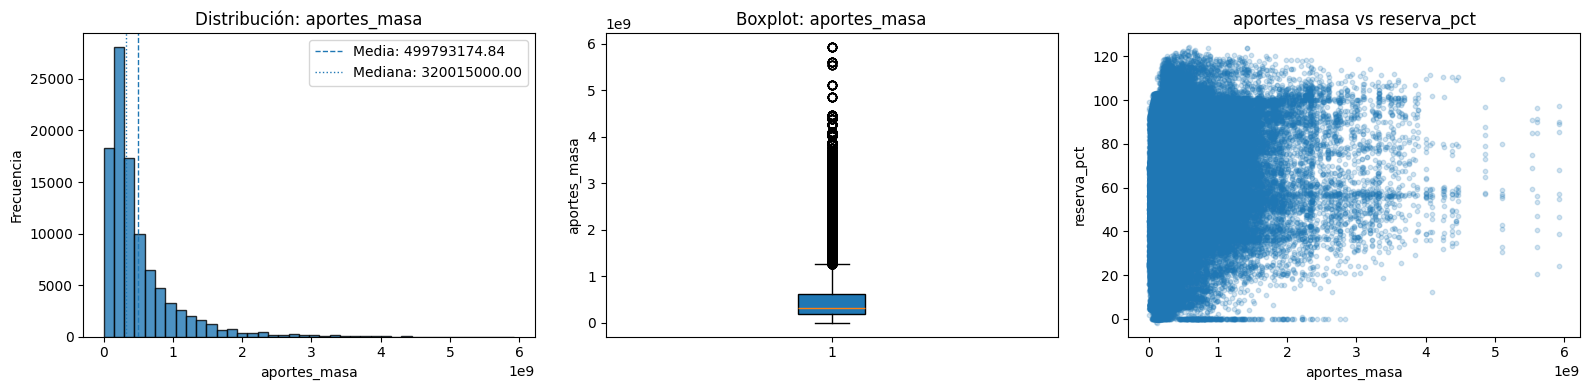

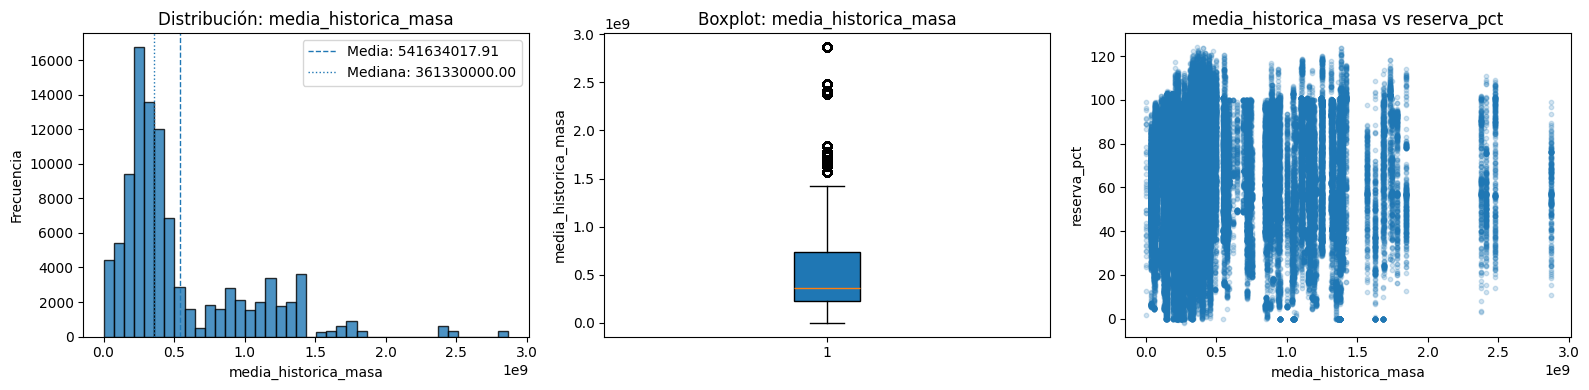

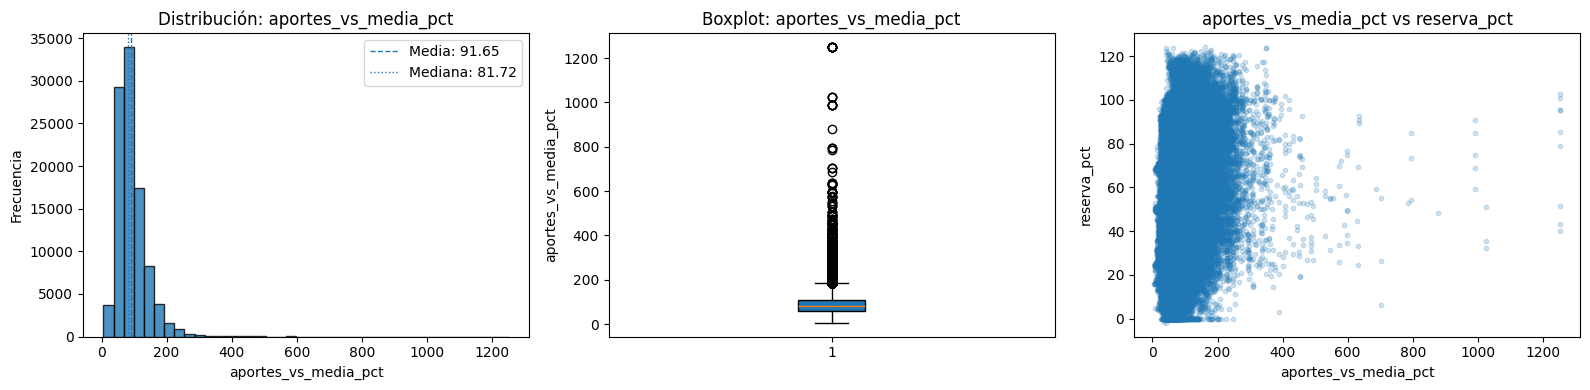

In [15]:
plot_numeric_audit(
    embalses,
    columns=[
        col for col in [
            "aportes_masa",
            "media_historica_masa",
            "aportes_vs_media_pct"
        ] if col in embalses.columns
    ],
    target="reserva_pct",
)

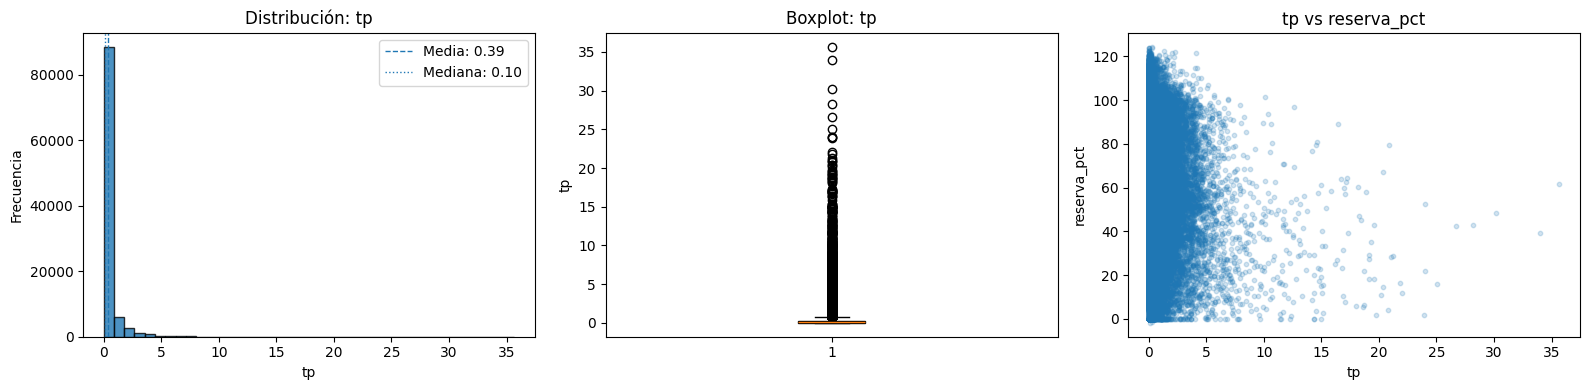

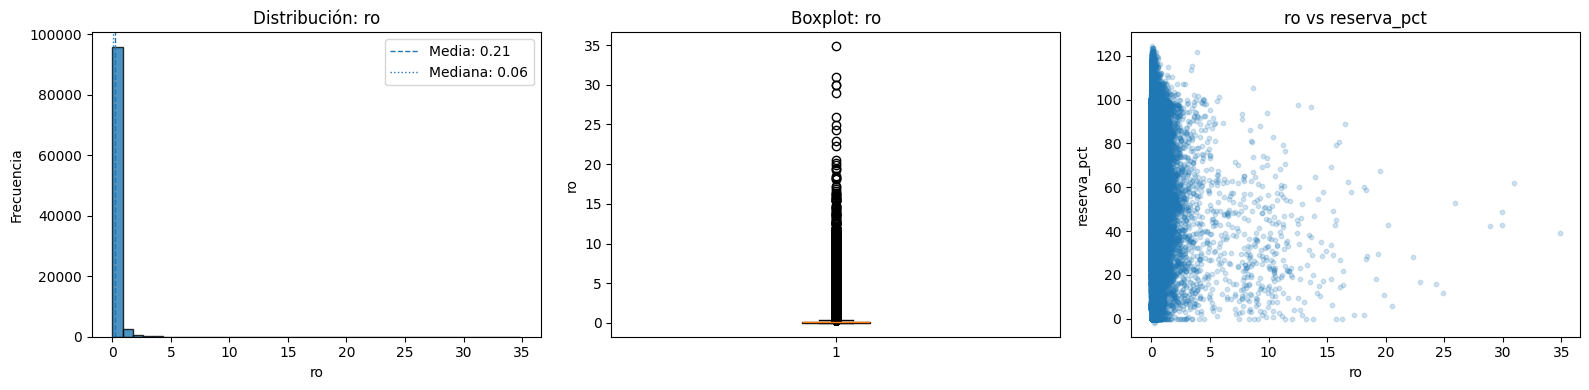

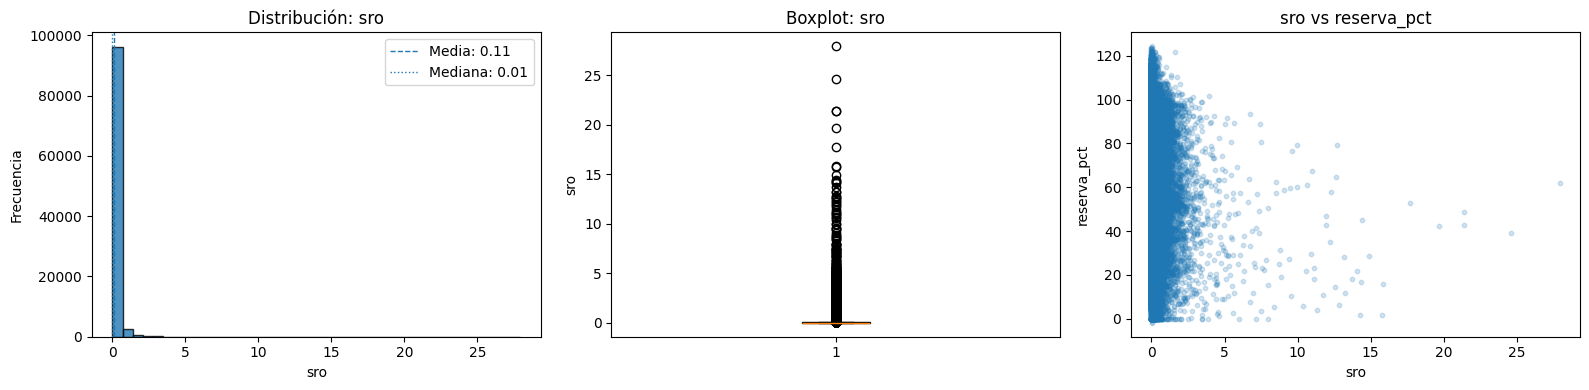

In [17]:
plot_numeric_audit(
    embalses,
    columns=[
        col for col in [
            "tp",
            "ro",
            "sro"
        ] if col in embalses.columns
    ],
    target="reserva_pct",
)

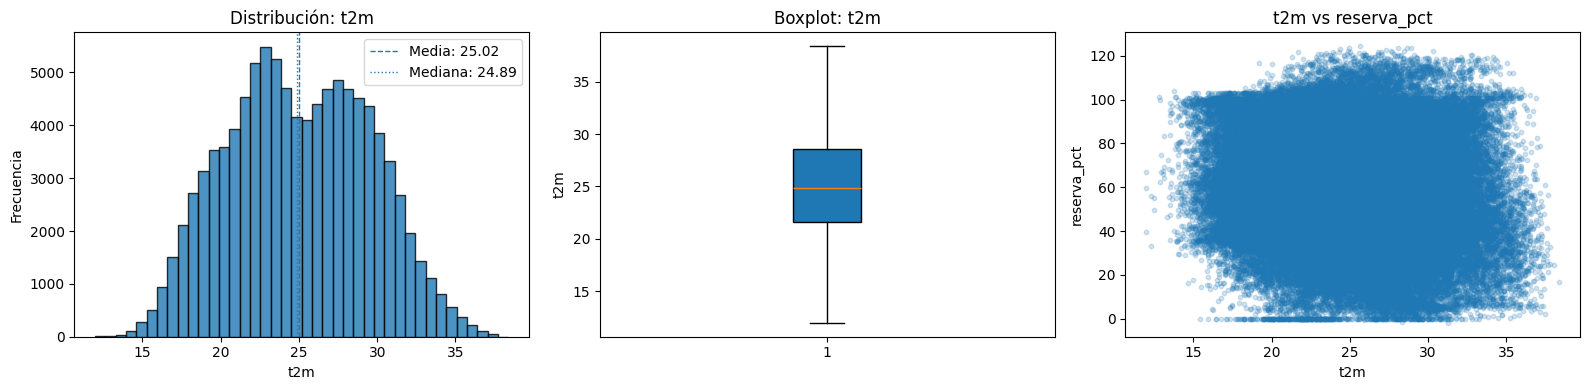

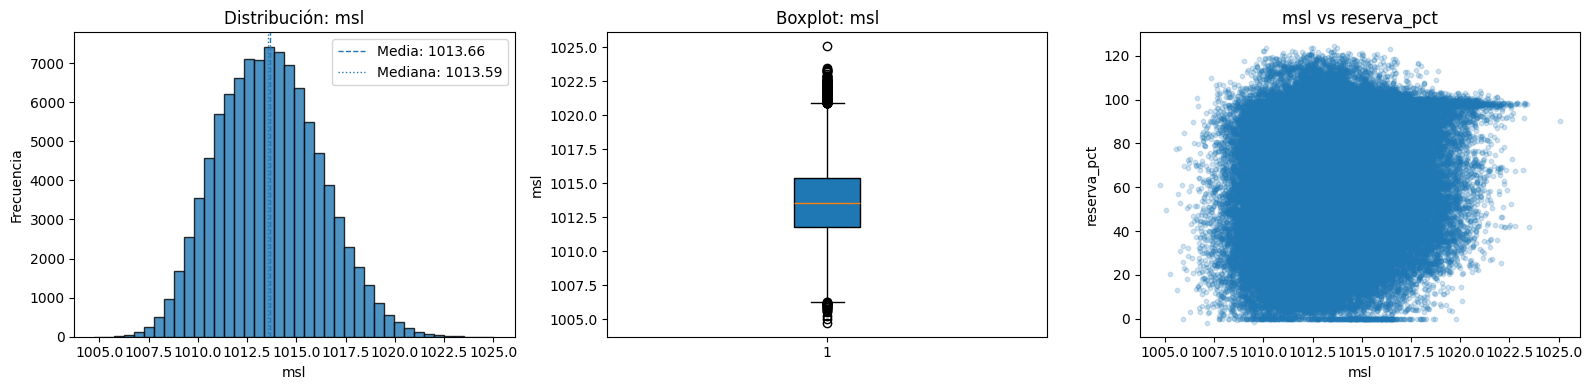

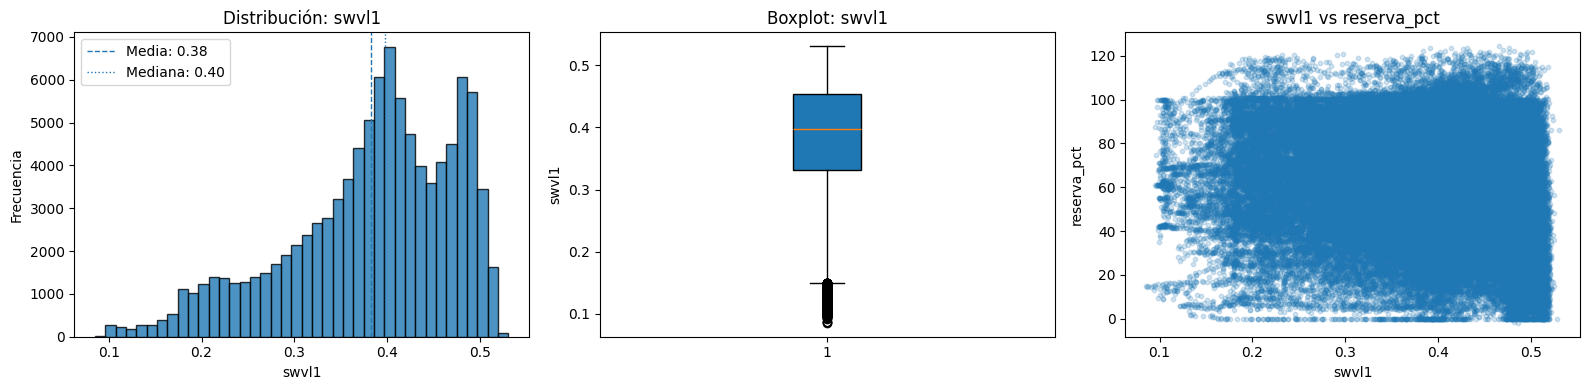

In [18]:
plot_numeric_audit(
    embalses,
    columns=[
        col for col in [
            "t2m",
            "msl",
            "swvl1"
        ] if col in embalses.columns
    ],
    target="reserva_pct",
)

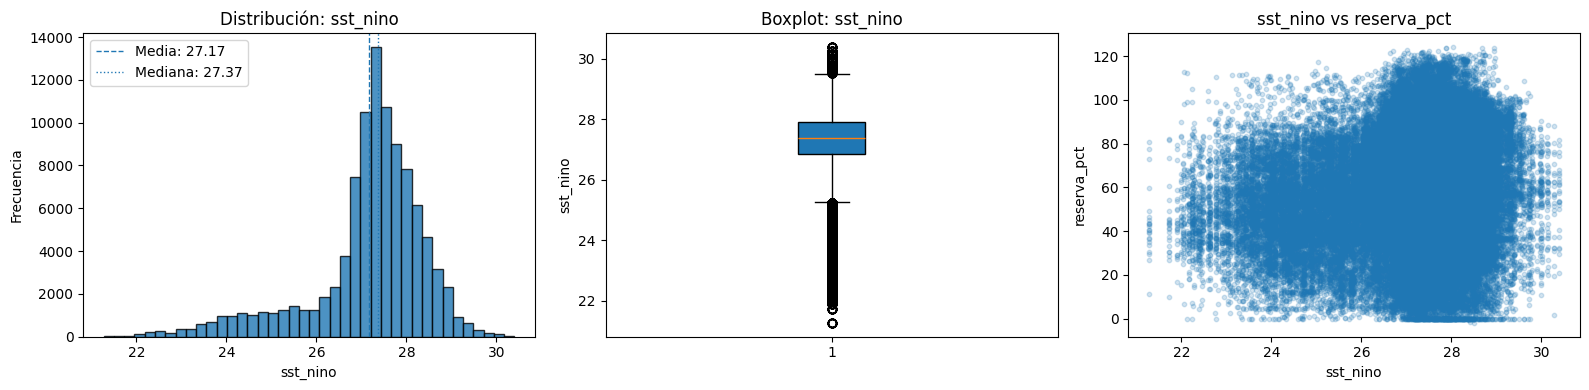

In [19]:
plot_numeric_audit(
    embalses,
    columns=[
        col for col in [
            "sst_nino"
        ] if col in embalses.columns
    ],
    target="reserva_pct",
)

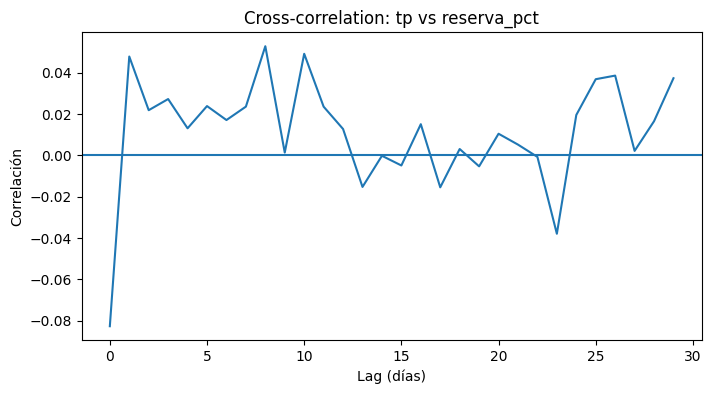

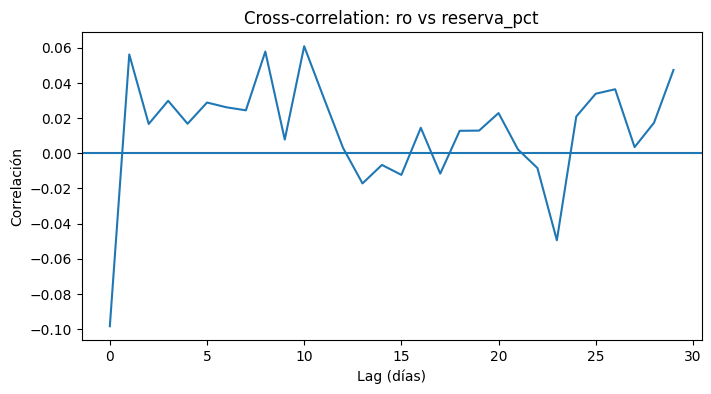

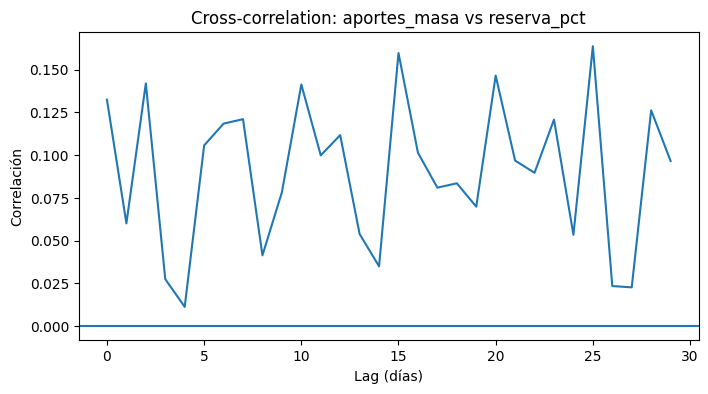

In [21]:
plot_cross_corr(embalses, "tp", "reserva_pct")
plot_cross_corr(embalses, "ro", "reserva_pct")
plot_cross_corr(embalses, "aportes_masa", "reserva_pct")

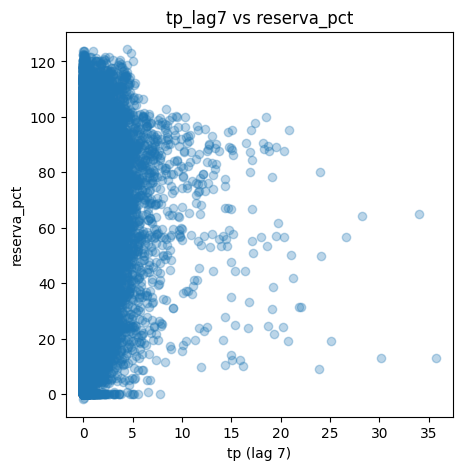

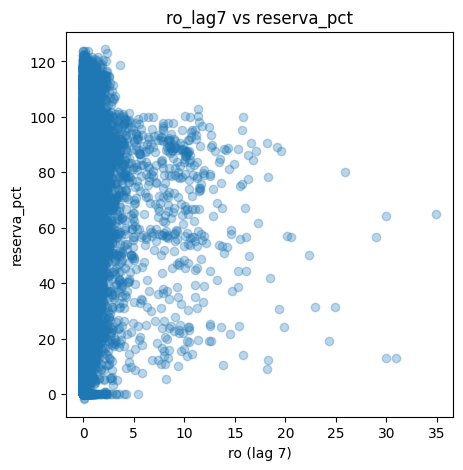

In [26]:
plot_lag_scatter(embalses, "tp", "reserva_pct", lag=7)
plot_lag_scatter(embalses, "ro", "reserva_pct", lag=7)

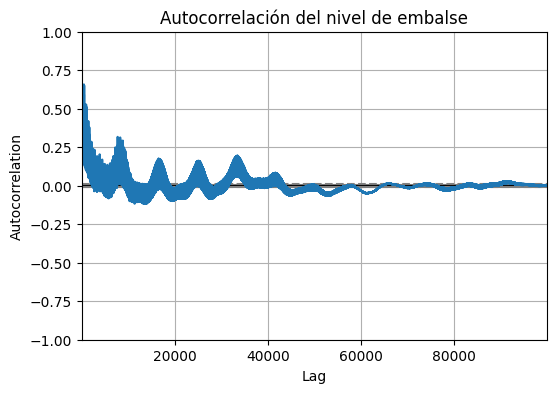

In [27]:
from pandas.plotting import autocorrelation_plot

plt.figure(figsize=(6,4))
autocorrelation_plot(embalses["reserva_pct"])
plt.title("Autocorrelación del nivel de embalse")
plt.show()

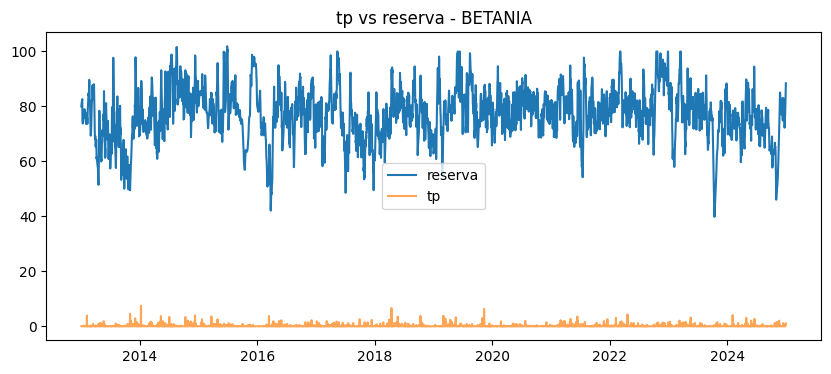

In [28]:
plot_time_series(embalses, "tp", "BETANIA")

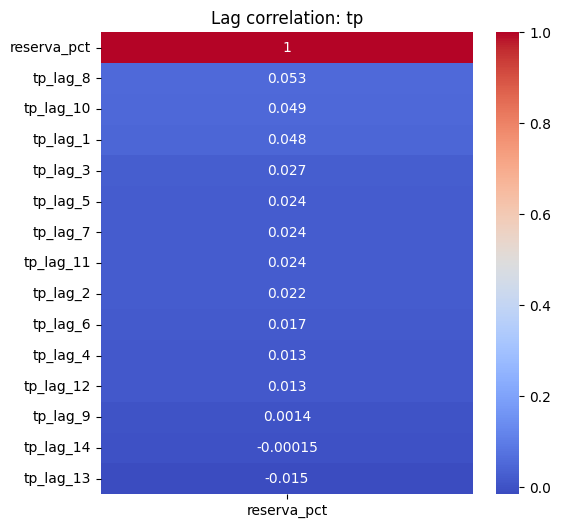

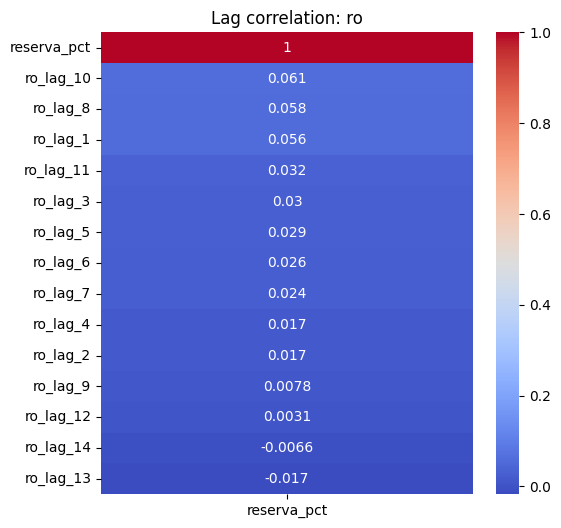

In [29]:
lag_corr_matrix(embalses, "tp", "reserva_pct")
lag_corr_matrix(embalses, "ro", "reserva_pct")

In [ ]:
quick_interpretation(embalses, target=TARGET, numeric_cols=numeric_cols)


                                 LECTURA RÁPIDA DEL EDA                                 
- Filas: 99,838
- Columnas: 17
- Target: reserva_pct
- Variables numéricas: 13
- Variables categóricas: 3
- Valores faltantes totales: 45
- Filas duplicadas exactas: 0


## Outliers

In [ ]:
embalses = embalses.query("reserva_pct > 0")

## Split

In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler, TargetEncoder, FunctionTransformer
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from category_encoders import BinaryEncoder


In [ ]:
SEED = 72

In [ ]:
base_feature_cols = [col for col in embalses.columns if col != TARGET]

X_full = embalses[base_feature_cols].copy()
y_full = embalses[TARGET].copy()

X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X_full,
    y_full,
    test_size=0.20,
    random_state=SEED,
)

print_section("PARTICIÓN DE DATOS")
print(f"Train shape: {X_train_raw.shape}")
print(f"Test shape:  {X_test_raw.shape}")
print(f"Target mean (train): {y_train.mean():,.3f}")
print(f"Target mean (test):  {y_test.mean():,.3f}")


                                   PARTICIÓN DE DATOS                                   
Train shape: (79563, 16)
Test shape:  (19891, 16)
Target mean (train): 62.542
Target mean (test):  62.617


## Feature engineering

In [ ]:

def add_engineered_features(df: pd.DataFrame) -> pd.DataFrame:
    """Add simple deterministic engineered features."""
    out = df.copy()
    
    out = out.replace([np.inf, -np.inf], np.nan)
    return out


X_train = add_engineered_features(X_train_raw)
X_test = add_engineered_features(X_test_raw)

print_section("FEATURE ENGINEERING BÁSICO")
print(f"Número de columnas antes: {X_train_raw.shape[1]}")
print(f"Número de columnas después: {X_train.shape[1]}")

new_columns = [col for col in X_train.columns if col not in X_train_raw.columns]
print(f"Nuevas variables: {new_columns}")


                               FEATURE ENGINEERING BÁSICO                               
Número de columnas antes: 16
Número de columnas después: 16
Nuevas variables: []


In [ ]:
temporal_cols = ["Fecha"]
binary_cols = ["CodigoEmbalse"]
onehot_cols = ["RegionHidrologica"]
numeric_cols_chunk2 = X_train.select_dtypes(include=[np.number]).columns.tolist()

print_section("MAPA SEMÁNTICO DE VARIABLES")
print(f"Numéricas ({len(numeric_cols_chunk2)}): {numeric_cols_chunk2}")
print(f"Binarias ({len(binary_cols)}): {binary_cols}")
print(f"OneHot ({len(onehot_cols)}): {onehot_cols}")
print(f"Temporales ({len(temporal_cols)}): {temporal_cols}")



                              MAPA SEMÁNTICO DE VARIABLES                               
Numéricas (13): ['aportes_masa', 'media_historica_masa', 'aportes_vs_media_pct', 't2m', 'u10', 'v10', 'msl', 'sst_nino', 'tp', 'ro', 'sro', 'swvl1', 'wind_speed']
Binarias (1): ['CodigoEmbalse']
OneHot (1): ['RegionHidrologica']
Temporales (1): ['Fecha']


In [ ]:
from category_encoders import BinaryEncoder

class BinaryEncoderWrapper(BinaryEncoder):
    def get_feature_names_out(self, input_features=None):
        return np.array(self.feature_names_in_)

In [ ]:
from sklearn.base import BaseEstimator, TransformerMixin
import numpy as np
import pandas as pd

class TemporalEncoder(BaseEstimator, TransformerMixin):
    def fit(self, X, y=None):
        self.n_features_in_ = X.shape[1]
        return self

    def transform(self, X):
        X = np.asarray(X)
        result = []

        for col in range(X.shape[1]):
            dates = pd.to_datetime(X[:, col])

            mes = dates.month
            dia_año = dates.dayofyear
            #año = dates.year
            #dias_desde_inicio = (dates - dates.min()).days 

            features = np.column_stack([
                np.sin(2 * np.pi * mes / 12),
                np.cos(2 * np.pi * mes / 12),
                np.sin(2 * np.pi * dia_año / 365),
                np.cos(2 * np.pi * dia_año / 365),
                #año,
                #dias_desde_inicio,
            ])

            result.append(features)

        return np.hstack(result)

    def get_feature_names_out(self, input_features):
        names = []
        for col in input_features:
            names.extend([
                f"{col}_mes_sin",
                f"{col}_mes_cos",
                f"{col}_dia_sin",
                f"{col}_dia_cos",
                #f"{col}_year",
                #f"{col}_days_from_start",
            ])
        return np.array(names)

In [ ]:
def build_preprocessor(
    numeric_cols: list[str],
    binary_cols: list[str],
    onehot_cols: list[str],
    temporal_cols: list[str],
    numeric_imputer_strategy: str = "median",
    scale_numeric: bool = True,
) -> ColumnTransformer:
    """Build a safe mixed-type preprocessor."""
    num_steps = [
        ("imputer", SimpleImputer(strategy=numeric_imputer_strategy)),
    ]

    if scale_numeric:
        num_steps.append(("scaler", StandardScaler()))

    numeric_pipe = Pipeline(num_steps)

    transformers = [
        ("num", numeric_pipe, numeric_cols),
    ]

    if onehot_cols:
        onehot_pipe = Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("encoder", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
        ])
        transformers.append(("nom", onehot_pipe, onehot_cols))

    if binary_cols:
        binary_pipe = Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("encoder", BinaryEncoder()),
        ])
        transformers.append(("binary", binary_pipe, binary_cols))

    if temporal_cols:
        temporal_pipe = Pipeline([
            ("encoder", TemporalEncoder()),
        ])
        transformers.append(("temp", temporal_pipe, temporal_cols))

    preprocessor = ColumnTransformer(
        transformers=transformers,
        remainder="drop",
    )
    return preprocessor

In [ ]:
preview_preprocessor = build_preprocessor(
    numeric_cols=numeric_cols_chunk2,
    binary_cols=binary_cols,
    onehot_cols=onehot_cols,
    temporal_cols=temporal_cols,
    numeric_imputer_strategy="median",
    scale_numeric=True,
)

X_train_t = preview_preprocessor.fit_transform(X_train)
X_test_t = preview_preprocessor.transform(X_test)

print_section("PREVIEW DEL PREPROCESSOR")
print(f"Shape train transformado: {X_train_t.shape}")
print(f"Shape test transformado:  {X_test_t.shape}")

feature_names = preview_preprocessor.get_feature_names_out()
preview_df = pd.DataFrame(X_train_t[:5], columns=feature_names)
display(preview_df)


                                PREVIEW DEL PREPROCESSOR                                
Shape train transformado: (79563, 28)
Shape test transformado:  (19891, 28)


,num__aportes_masa,num__media_historica_masa,num__aportes_vs_media_pct,num__t2m,num__u10,num__v10,num__msl,num__sst_nino,num__tp,num__ro,...,nom__RegionHidrologica_Valle,binary__0_0,binary__0_1,binary__0_2,binary__0_3,binary__0_4,temp__Fecha_mes_sin,temp__Fecha_mes_cos,temp__Fecha_dia_sin,temp__Fecha_dia_cos
0,0.047640,0.042404,0.042815,-1.335616,1.040303,-0.467401,0.599811,-0.535622,-0.343702,-0.235304,...,0.0,0.0,0.0,0.0,0.0,1.0,5.000000e-01,0.866025,0.417194,0.908818
1,-0.038452,0.850583,-0.855940,-0.482567,0.600653,0.947767,2.050504,1.601484,-0.301842,-0.158906,...,0.0,0.0,0.0,0.0,1.0,0.0,-8.660254e-01,-0.500000,-0.854322,-0.519744
2,-0.520855,-0.454916,-0.518548,-0.177089,-1.350735,0.901623,0.167428,0.667156,-0.389842,-0.229759,...,0.0,0.0,0.0,0.0,1.0,1.0,-5.000000e-01,-0.866025,-0.361714,-0.932289
3,-0.330836,-0.182464,-0.441744,-0.410427,0.316571,-0.367552,0.213985,0.311960,0.984857,-0.026442,...,0.0,0.0,0.0,0.0,1.0,1.0,-8.660254e-01,0.500000,-0.995919,0.090252
4,-0.400041,-0.474013,-0.048928,1.071895,-0.394451,0.530102,-0.074357,1.550659,-0.391269,-0.230067,...,0.0,0.0,0.0,1.0,0.0,0.0,1.224647e-16,-1.000000,0.377708,-0.925925


In [ ]:
def regression_report(y_true: pd.Series, y_pred: np.ndarray) -> dict:
    """Return a compact regression metrics dictionary."""
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    return {
        "rmse": rmse,
        "mae": mae,
        "r2": r2,
    }


def evaluate_pipeline(
    estimator,
    X_train_data: pd.DataFrame,
    X_test_data: pd.DataFrame,
    y_train_data: pd.Series,
    y_test_data: pd.Series,
    tag: str,
) -> dict:
    """Fit estimator and return metrics."""
    estimator.fit(X_train_data, y_train_data)
    preds = estimator.predict(X_test_data)
    report = regression_report(y_test_data, preds)
    report["experiment"] = tag
    return report

In [ ]:
results = []

preprocessor = build_preprocessor(
    numeric_cols=numeric_cols_chunk2,
    binary_cols=binary_cols,
    onehot_cols=onehot_cols,
    temporal_cols=temporal_cols,
    numeric_imputer_strategy="median",
    scale_numeric=True,
)

model = Pipeline([
    ("preprocess", preprocessor),
    ("regressor", DecisionTreeRegressor(max_depth=8, random_state=SEED)),
])

result = evaluate_pipeline(
    estimator=model,
    X_train_data=X_train,
    X_test_data=X_test,
    y_train_data=y_train,
    y_test_data=y_test,
    tag=f"Baseline",
)
results.append(result)

imputation_results_df = pd.DataFrame(results).sort_values("rmse")
print_section("RESULTADOS — IMPUTACIÓN")
display(imputation_results_df)


                                RESULTADOS — IMPUTACIÓN                                 


,rmse,mae,r2,experiment
0,18.358227,14.279058,0.454007,Baseline
